# Q1 VAE, Q2 Score Matching
In this notebook, we will implement the VAEs and Score Matching ([Noise-Conditioned Score Network](https://arxiv.org/abs/1907.05600)) models and compare their performance on the swiss roll dataset. We will also use NCSNs to generate MNIST images.

## Workflow

To start, you will implement the network architectures defined in `vae.py` and `score.py`. You can use this Jupyter Notebook for testing your implementation and visualizing your results. You don't need a serious GPU for these.

To facilitate your testing, either enable the autoreload extension so that your modifications to the `.py` files will be automatically reloaded, or restart your notebook kernel after updating `.py` files. In our testing, we found the autoreload extension somewhat finicky and had to restart the kernel for it to pickup the changed files for some parts.
    


In [9]:
# Uncomment the following pip command to install requirements
# NOT needed if you are using the virtual env /work/nvme/bfdu/cs444/fa25/mp5-q1-q2/venv/ on Delta AI
# ! pip install -r requirements_Q1_Q2.txt

In [2]:
# loading autoreload extension for jupyter
%load_ext autoreload
%autoreload 2

In [10]:
import os
import unittest
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

from vae import VAE
from score import ScoreNet
from networks import SimpleDecoder, SimpleEncoder

### Swiss Roll Dataset

In [11]:
def make_swiss_roll(n_samples=100, *, noise=0.0, seed=None):
    generator = torch.Generator()
    generator.manual_seed(seed)
    t = 1.5 * np.pi * (1 + 2 * torch.rand(n_samples, generator=generator))
    x = t * torch.cos(t)
    y = t * torch.sin(t)

    X = torch.stack((x, y), dim=1)
    X += noise * torch.randn(n_samples, 2, generator=generator)
    return X, t

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

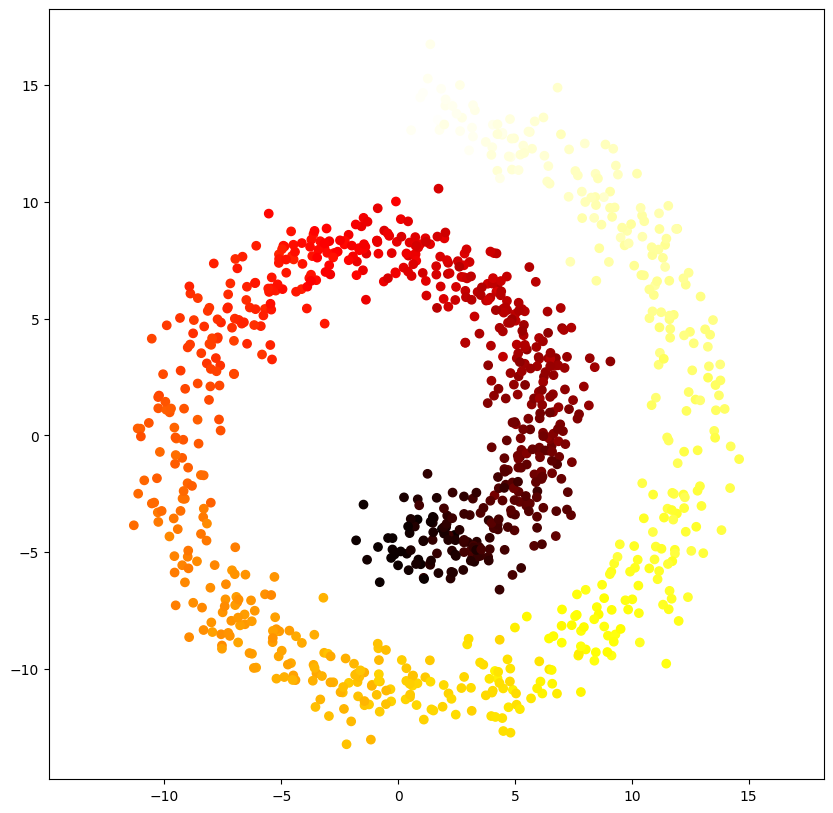

In [12]:
X, t = make_swiss_roll(n_samples=1000, noise=1., seed=42)
plt.figure(figsize=(10, 10))
plt.scatter(X[:, 0], X[:, 1], c=t, cmap=plt.cm.hot)
plt.axis('equal')
plt.show()

## Q1. VAE (Swiss Roll)

**Q1.1 [1 pts Autograded]** Implement the `reparameterize` method in `vae.py`. This method takes in the mean and log-variance of the latent distribution and returns a sample from the distribution.

Once you have implemented the method, run the following cell to test your implementation.

In [13]:
suite = unittest.TestLoader().loadTestsFromName('test_models.TestModels.test_vae_reparam')
unittest.TextTestRunner().run(suite)

.
----------------------------------------------------------------------
Ran 1 test in 0.103s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

**Q1.2 [3 pts Autograded]** Implement the `get_loss` method in `vae.py`. This method takes in a batch of data and returns the VAE loss. You should compute the reconstruction loss and the KL divergence loss and return the sum of the two losses. The reconstruction loss is the **mean squared error** between the reconstructed images and the original images. The KL divergence loss can be computed in closed form, and you should **sum** it along latent dimensions.

**Hint**. The KL-divergence between a Gaussian distribution with mean $\mu$ and variance $\sigma^2$ and a standard Gaussian distribution $\mathcal{N}(0,1)$ is given by:

$$
\mathcal{D}_{\text{KL}}(\mathcal{N}(\mu, \sigma^2) || \mathcal{N}(0, 1)) = \frac{1}{2}\left( \sigma^2 + \mu^2 - 1 - \log \sigma^2 \right)
$$

Once you have implemented the method, run the following cell to test your implementation.

In [14]:
suite = unittest.TestLoader().loadTestsFromName('test_models.TestModels.test_vae_loss')
unittest.TextTestRunner().run(suite)

.
----------------------------------------------------------------------
Ran 1 test in 0.047s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

Now train your VAE model on the Swiss roll dataset and try to generate some points after training.

In [15]:
vae = VAE(
    SimpleEncoder(input_size=2, hidden_size=128, latent_size=10 * 2),
    SimpleDecoder(latent_size=10, hidden_size=128, output_size=2)
)
print(f'Number of parameters in VAE: {count_parameters(vae)}')
vae.train()

optimizer = optim.Adam(vae.parameters(), lr=1e-3)
for epoch in range(2000):
    optimizer.zero_grad()
    loss = vae.get_loss(X)
    loss.backward()
    optimizer.step()
    if epoch % 200 == 0:
        print(f'Epoch {epoch}, loss {loss.item():.4f}')
print('Done!')

Number of parameters in VAE: 37654
Epoch 0, loss 51.7266
Epoch 200, loss 6.1206
Epoch 400, loss 4.7977
Epoch 600, loss 4.7118
Epoch 800, loss 4.8000
Epoch 1000, loss 4.7093
Epoch 1200, loss 4.6853
Epoch 1400, loss 4.7085
Epoch 1600, loss 4.6582
Epoch 1800, loss 4.6779
Done!


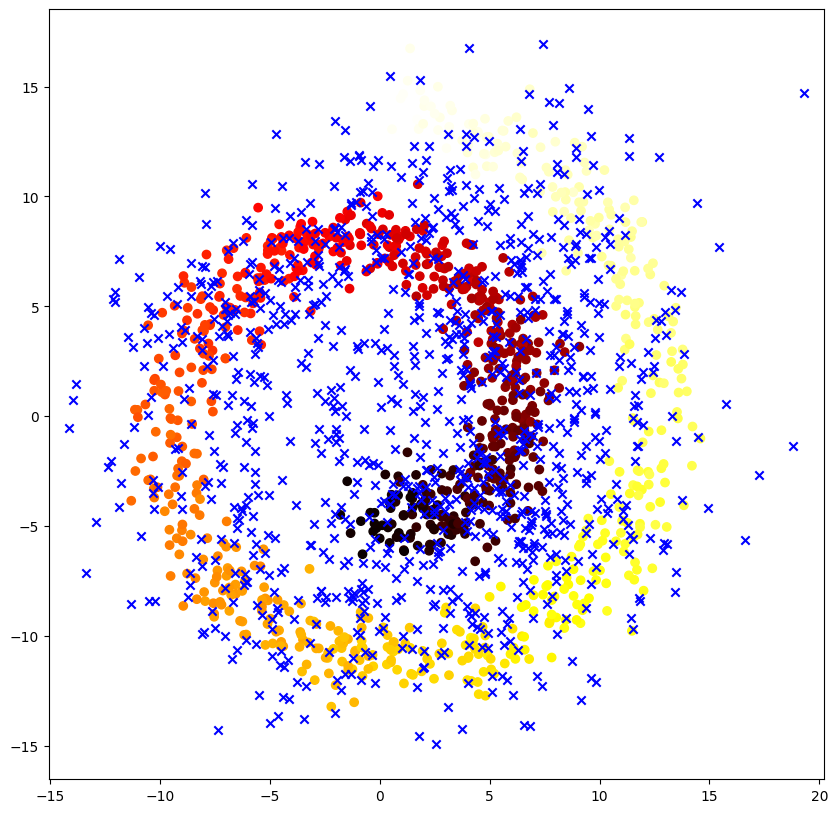

In [16]:
n_sample = 1000
vae.eval()
with torch.no_grad():
    X_gen = vae.sample(n_sample, 'cpu')
plt.figure(figsize=(10, 10))
plt.scatter(X[:, 0], X[:, 1], c=t, cmap=plt.cm.hot)
plt.scatter(X_gen[:, 0], X_gen[:, 1], c='b', marker='x')
plt.axis('equal')
plt.show()

## Q2: Score Matching (Swiss Roll)

In this part, you are expected to implement the score matching model on the Swiss roll dataset.

**Q2.1 [2 pts Autograded]** Implement the `perturb` method in `score.py`. This function takes in a batch of data and returns a perturbed batch of data. Specifically, you should first choose uniformly random from `self.simgas` for each data (NOT each pixel/coordinate!). Then add the Gaussian noise the data with standard deviation `sigma`. Return the applied noise and used sigma values. DO NOT clip the perturbed data!

Once you have implemented the method, run the following cell to test your implementation.

In [17]:
suite = unittest.TestLoader().loadTestsFromName('test_models.TestModels.test_score_perturb')
unittest.TextTestRunner().run(suite)

.
----------------------------------------------------------------------
Ran 1 test in 0.286s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

**Q2.2 [3 pts Autograded]** Implement the `get_loss` method in `score.py`. You should first call `perturb` to obtain the noise and perturbed data and call `get_score` to obtain the estimated scores for the perturbed data. The score loss in NCSNv2 is defined as:

$$
\mathcal{L}_{\text{score}} = \frac{1}{2}\mathbb{E}_{\sigma} \mathbb{E}_{\hat{\mathbf{x}}\sim p(\mathbf{\hat{x}},\mathbf{x})} \left[ \left( s(\hat{\mathbf{x}}) - \frac{\mathbf{x} - \mathbf{\hat{x}}}{\sigma^2} \right)^2\cdot \sigma^2 \right]
$$

where $\mathbf{x}$ is the original data and $\mathbf{\hat{x}}$ is the perturbed data. $\sigma$ is the standard deviation of the noise, and $s(\hat{\mathbf{x}})$ is the estimated score for the perturbed data. The loss should be **averaged** over the batch dimension and the image dimensions.

Once you have implemented the method, run the following cell to test your implementation.

In [18]:
suite = unittest.TestLoader().loadTestsFromName('test_models.TestModels.test_score_loss')
unittest.TextTestRunner().run(suite)

.
----------------------------------------------------------------------
Ran 1 test in 0.152s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

**Q2.3 [2 pts Autograded]** Complete the `sample` method in `score.py`. Recall that in Langevin dynamics, the update rule is:

$$
\mathbf{x}_{t+1} = \mathbf{x}_t + \eta\nabla_{\mathbf{x}}\log p(\mathbf{x}) + \sqrt{2\eta}\mathbf{z}_t
$$

where $\mathbf{z}_t\sim \mathcal{N}(0, \mathbf{I})$. In this method, we first sample a batch of noise $\mathbf{z}_t$ and estimate the scores (gradient of the log density $\nabla_{\mathbf{x}}\log p(\mathbf{x})$) using `get_score`. Then you should compute the update $\mathbf{x}_{t+1}$ and return the sequence of updates.

Once you have implemented the method, run the following cell to test your implementation.


In [19]:
suite = unittest.TestLoader().loadTestsFromName('test_models.TestModels.test_score_sample')
unittest.TextTestRunner().run(suite)

.
----------------------------------------------------------------------
Ran 1 test in 0.046s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

In [20]:
scorenet = ScoreNet(
    torch.nn.Sequential(
        SimpleEncoder(input_size=2, hidden_size=128, latent_size=16),
        SimpleDecoder(latent_size=16, hidden_size=128, output_size=2),
    ), 10., 0.1, 20, 'geometric'
)
scorenet.train()
optimizer = optim.Adam(scorenet.parameters(), lr=1e-3)
for epoch in range(2000):
    optimizer.zero_grad()
    loss = scorenet.get_loss(X)
    loss.backward()
    optimizer.step()
    if epoch % 200 == 0:
        print(f'Epoch {epoch}, loss {loss.item():.4f}')
print('Done!')

Epoch 0, loss 0.5120
Epoch 200, loss 0.4301
Epoch 400, loss 0.4421
Epoch 600, loss 0.4400
Epoch 800, loss 0.4211
Epoch 1000, loss 0.4367
Epoch 1200, loss 0.4148
Epoch 1400, loss 0.3894
Epoch 1600, loss 0.4205
Epoch 1800, loss 0.4450
Done!


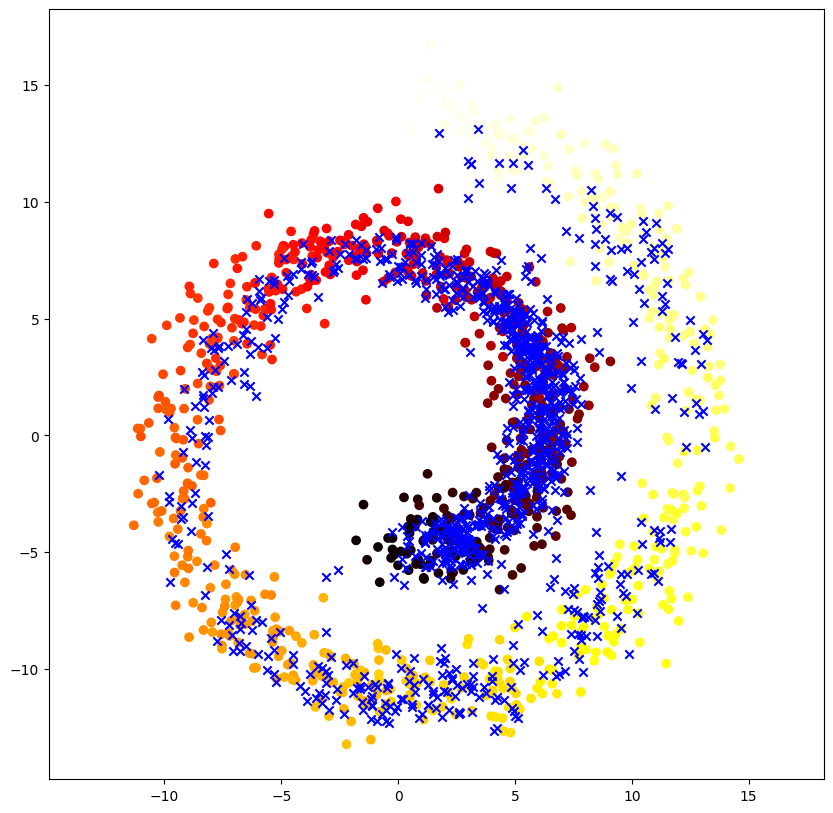

In [28]:
n_sample = 1000
scorenet.eval()
with torch.no_grad():
    X_gen = scorenet.sample(n_sample, 2, step_lr=0.01)[-1, -1]
plt.figure(figsize=(10, 10))
plt.scatter(X[:, 0], X[:, 1], c=t, cmap=plt.cm.hot)
plt.scatter(X_gen[:, 0], X_gen[:, 1], c='b', marker='x')
plt.axis('equal')
plt.show()

**Q2.4 [1 pts Manual graded]** Compare the sampled points from VAE and score matching and upload the visualization. Which model do you think performs the best?

**Q2.5 [1 pts Manual graded]** Modify the `step_lr` argument in the score-matching sampling and rerun the sampling for at least three different step sizes. Upload the visualization and discuss the effect of the step size on the sampling.